# Week 4 — Embeddings, Similarity & Modalities  
### *Understanding How Meaning Becomes Geometry*

<a href="https://colab.research.google.com/github/tulane-intro-ai-engineering/main/blob/main/lectures/week4_embeddings_similarity.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

---

### 🎯 Learning Objectives
By the end of this week, you should be able to:
- Explain what an **embedding** is and how it represents meaning numerically.  
- Compute and interpret **cosine similarity** between vectors.  
- Describe **how embeddings are learned** from data.  
- Distinguish **semantic search** from **keyword search** conceptually.  
- Understand **why cosine** works better than Euclidean distance for meaning.  
- Describe how **multimodal embeddings** connect text and images.  
- Locate embeddings within the **Unifying System Diagram (v3)**.


In [1]:
# @title Setup (Run this first)
!git clone -q https://github.com/tulane-intro-ai-engineering/main.git
import sys; sys.path.append('/content/main')
from course_utils import lab4_setup, show_mermaid
lab4_setup()
print("✅ Environment ready!")

Enter your OpenAI API key. It will only live in this Colab runtime.
OpenAI API key: ··········
✅ API key set.
✅ Environment ready!


# 🧭 Day 1 — From Words to Meaning Spaces

Today, we’ll build intuition for **embeddings** — how models represent meaning using numbers — and explore how **geometry captures similarity**.


## 🌟 Motivating Example — “Cardiac Doctor” vs Keyword Search

Let’s compare keyword and semantic search for the query **“cardiac doctor.”**  
Keyword search fails because it only matches *exact words*, while embeddings recognize *meaning-level similarity*.


In [2]:
# @title Keyword vs Semantic Search Demo
from openai import OpenAI
import numpy as np
client = OpenAI()

query = "cardiac doctor"
docs = [
    "A cardiologist treats heart disease.",
    "This is about car engines.",
    "Nutrition and exercise matter.",
]

# Keyword search
keyword_hits = [d for d in docs if any(w in d.lower() for w in query.split())]

# Semantic similarity
def cosine(a,b): return np.dot(a,b)/(np.linalg.norm(a)*np.linalg.norm(b))
q_embed = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding
doc_embeds = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
sims = [cosine(q_embed, e) for e in doc_embeds]
ranked = [x for _,x in sorted(zip(sims, docs), reverse=True)]

print("🔹 Keyword search:", keyword_hits)
print("🔸 Semantic search:", ranked[:2])


🔹 Keyword search: []
🔸 Semantic search: ['A cardiologist treats heart disease.', 'Nutrition and exercise matter.']


**Discussion:**  
- Keyword search misses “cardiologist” even though it’s the correct answer.  
- Semantic search succeeds by comparing *meaning*, not literal words.  


## 🔢 From Words to Numbers

Models represent each word as a **vector** of numbers — points in a high-dimensional space.  
Let’s visualize a tiny, 2D “toy embedding space.”


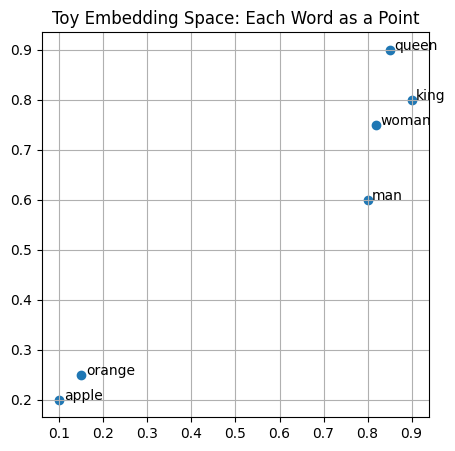

In [3]:
# @title Toy Example — 2D Word Vectors
import matplotlib.pyplot as plt
import numpy as np

words = ["king", "queen", "apple", "orange", "man", "woman"]
vectors = np.array([
    [0.9, 0.8],
    [0.85, 0.9],
    [0.1, 0.2],
    [0.15, 0.25],
    [0.8, 0.6],
    [0.82, 0.75],
])

plt.figure(figsize=(5,5))
plt.scatter(vectors[:,0], vectors[:,1])
for i, w in enumerate(words):
    plt.text(vectors[i,0]+0.01, vectors[i,1], w)
plt.title("Toy Embedding Space: Each Word as a Point")
plt.grid(True)
plt.show()


**Reflection:**  
If “king” and “queen” are close together, what might their coordinates have in common?  
What might differ?


## 🧩 How Are Word Embeddings Learned?

Embeddings aren’t hand-coded — they’re **learned** from text data.

1. **Distributional Hypothesis:** Words appearing in similar contexts have similar meanings.  
2. **Training Idea:** Predict context words from a target word (skip-gram model).  
3. **Optimization:** Adjust vectors so that related words (e.g., “dog”–“bark”) have similar directions.  

Let’s simulate a **mini skip-gram training** process.


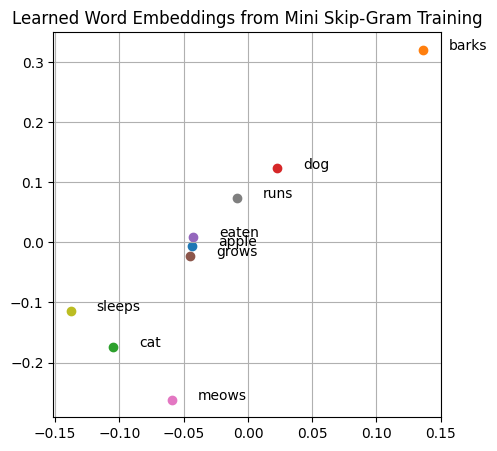

In [4]:
# @title Mini Skip-Gram Training Simulation
import numpy as np, matplotlib.pyplot as plt

sentences = [
    ["dog", "barks"],
    ["dog", "runs"],
    ["cat", "meows"],
    ["cat", "sleeps"],
    ["apple", "grows"],
    ["apple", "eaten"],
]

vocab = sorted({w for s in sentences for w in s})
word2idx = {w: i for i, w in enumerate(vocab)}

np.random.seed(42)
embeddings = np.random.randn(len(vocab), 2) * 0.3

pairs = []
for s in sentences:
    for i, w in enumerate(s):
        for j in range(max(0, i-1), min(len(s), i+2)):
            if i != j:
                pairs.append((w, s[j]))

lr = 0.05
epochs = 100

def cosine(a, b): return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

for _ in range(epochs):
    for center, context in pairs:
        c, ctx = word2idx[center], word2idx[context]
        v_c, v_ctx = embeddings[c], embeddings[ctx]
        sim = cosine(v_c, v_ctx)
        grad = lr * (1 - sim) * (v_ctx - v_c)
        embeddings[c] += grad
        embeddings[ctx] -= grad

plt.figure(figsize=(5, 5))
for w, vec in zip(vocab, embeddings):
    plt.scatter(*vec)
    plt.text(vec[0]+0.02, vec[1], w)
plt.title("Learned Word Embeddings from Mini Skip-Gram Training")
plt.grid(True)
plt.show()


**Reflection:**  
- Which words ended up close together?  
- Why are “dog” and “barks” near each other?  
- What would happen if we had more dimensions or data?


# 🚀 Day 2 — From Similarity to Semantic Systems

Today we’ll connect embeddings to **semantic search systems**, **multimodal models**, and the **Unifying Diagram v3**.


## 🔍 What Is Semantic Search?

**Definition:**  
Semantic search retrieves documents based on **meaning similarity** rather than exact word matches.

| Type | How it Works | Example Behavior |
|------|---------------|------------------|
| Keyword search | Matches literal text | “cardiac doctor” ≠ “cardiologist” |
| Semantic search | Uses vector similarity | “cardiac doctor” ≈ “cardiologist” |


## 📊 Visualizing an Embedding Store
Each document becomes a point in vector space.  
A query is another point — nearby ones are retrieved.


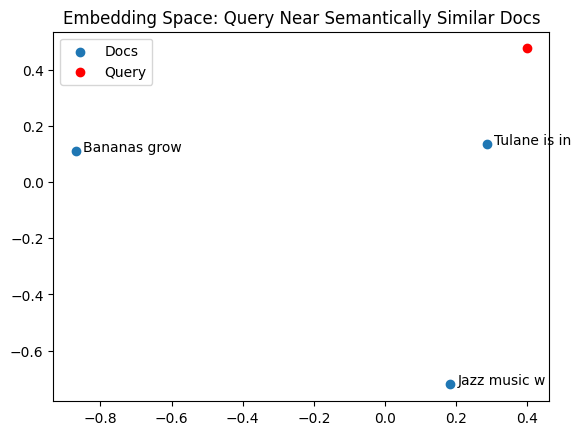

In [5]:
# @title PCA Visualization of Embedding Space
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

docs = ["Tulane is in Louisiana.", "Jazz music was born in New Orleans.", "Bananas grow in tropical climates."]
query = "Louisiana university"
doc_embs = [client.embeddings.create(input=d, model="text-embedding-3-small").data[0].embedding for d in docs]
q_emb = client.embeddings.create(input=query, model="text-embedding-3-small").data[0].embedding

pca = PCA(n_components=2)
points = pca.fit_transform(doc_embs + [q_emb])
plt.scatter(points[:-1,0], points[:-1,1], label='Docs')
plt.scatter(points[-1,0], points[-1,1], c='red', label='Query')
for i,d in enumerate(docs): plt.text(points[i,0]+0.02, points[i,1], d[:12])
plt.legend(); plt.title("Embedding Space: Query Near Semantically Similar Docs")
plt.show()


## ⚖️ Cosine vs Euclidean — Why Direction Matters

Cosine focuses on *direction* (meaning), while Euclidean measures *distance* (magnitude).  
Two identical directions with different lengths still have cosine similarity ≈ 1.


In [6]:
# @title Cosine vs Euclidean Example
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
A = np.array([1,2]); B = np.array([2,4])
print("Cosine similarity:", cosine_similarity([A],[B])[0][0])
print("Euclidean distance:", euclidean_distances([A],[B])[0][0])


Cosine similarity: 0.9999999999999999
Euclidean distance: 2.23606797749979


**Takeaway:**  
Even though B is twice as long, the angle between A and B is zero — so they *mean* the same thing.  
Cosine similarity focuses on meaning; Euclidean cares about magnitude.


## 🧠 Concept Check

Answer these questions in your own words before revealing the solutions:

1. What does cosine similarity measure between two vectors?  
2. Why do we prefer cosine over Euclidean distance for embeddings?  
3. How can text and images be compared using embeddings?


In [ ]:
# @title ✅ Reveal Answers
answers = {
    "1": "The angle between vectors — smaller angle = more similar meaning.",
    "2": "Cosine ignores magnitude and focuses on direction, which encodes meaning.",
    "3": "By projecting both into the same embedding space (e.g., CLIP)."
}
for q, a in answers.items():
    print(f"{q}. {a}")


## 🧩 Unifying Diagram v3 — Adding the Embedding Store

Embeddings power the retrieval module used in systems like RAG.


In [ ]:
# @title Unifying Diagram v3
show_mermaid("""
graph TD
    subgraph User Interaction
    U["User<br/>Query/Input"]:::user --> IH["Input Handling<br/>Formatting, Validation"]:::process
    end
    subgraph Prompt & Control
    IH --> PC("Prompt / Control<br/>Instructions, Examples, Params"):::control
    end
    subgraph Tools & Augmentation
    PC --> RAG{"Retrieval (RAG)<br/>• Embeddings<br/>• Vector Store<br/>• Top-k Search"}:::tool
    end
    subgraph Core LLM
    RAG --> LLM["LLM (Model)<br/>Next-token Prediction"]:::model
    PC --> LLM
    end
    subgraph Output & Monitoring
    LLM --> OP["Output Processing<br/>Formatting, Citations, Trust Signals"]:::output --> O("Final Output"):::output
    O --> LM["Logging & Monitoring<br/>Prompts, Metrics, Drift Detection"]:::monitor
    end
""")


<details>
<summary>📘 Instructor Notes</summary>

**Day 1**
- (10 min) Review Lab 3 pipeline findings  
- (15 min) Motivating example — “cardiac doctor” vs keyword search  
- (15 min) Concept: Words → Vectors (visual + reflection)  
- (20 min) How Embeddings Are Learned (skip-gram simulation)  
- (10 min) Discussion + wrap-up quiz  

**Day 2**
- (10 min) Recap and semantic search definition  
- (15 min) PCA visualization activity  
- (10 min) Cosine vs Euclidean comparison  
- (20 min) Multimodal embedding (CLIP) example discussion  
- (10 min) Unifying diagram and wrap-up  

**Prompts**
- What happens if embeddings are poorly trained?  
- How could you evaluate embedding quality?  
- How do multimodal embeddings help unify perception and language?
</details>
